# NB2 — Well Conditioning + Joint GMM (REVISED)

## Tujuan
1. Klasifikasi litofacies rule-based: Shale / Wet Sand / HC Sand
2. **Joint GMM training (P2 hybrid + P9)** untuk P(R, m) — dilatih di **seluruh interval Montara → Nome**
3. **Calibrate Σ₀ prior (P4)** dari well log untuk dipakai NB6
4. Crossplot dengan **RPT overlay** + density contour + per-facies stats (P14)
5. 9-Track log plot dengan VP_GASSMANN/VS_GASSMANN/LITHO terisi

## Input (`pipeline_data/01_well_qc/`)
- `CFG.pkl`, `WELL_TOPS.pkl`, `<wellname>.parquet`
- Data input sudah dalam bentuk RPM: **VP_GASSMANN, VS_GASSMANN, RHO_GASSMANN, VSH, PHIE** tersedia langsung

## Output (`pipeline_data/02_well_cond/`)
- `<wellname>.parquet` — DataFrame dengan VSH, PHIE, LITHO, VP_GASSMANN, VS_GASSMANN, RHO_GASSMANN
- `SHARED_GMM.joblib` — joint GMM 6D
- `SHARED_GMM_FEATS.pkl` — feature names list
- `SIGMA0_PRIOR.npz` — calibrated 3×3 prior covariance dari well log (P4)
- `gmm_diagnostics.json` — separability metrics, confusion matrix

## Perbaikan dari versi lama
- **P2 hybrid (A+B)**: Rule-based label init means → GMM fit → auto-permute → verify ordering
- **P9**: GMM dilatih di **Montara→Nome** (cover seluruh window seismik)
- **P10**: Clipping bounds dari `CFG['clip_bounds_inversion']`
- **P11**: rho_clay=2.55 dari CFG (hardcode dihapus)
- **P13**: 9-track plot dari `plot_utils`
- **P14**: Crossplot template dengan RPT overlay
- **P4**: Σ₀ prior dikalibrasi dari well log


## Cell 1 — Imports + load output NB1


In [13]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sys.path.insert(0, str(Path.cwd()))
from pipeline_io import PipelineIO
import plot_utils
import rpm_utils
import inversion_utils

warnings.filterwarnings("ignore")
np.random.seed(42)

print("=" * 72)
print("  NB2 — WELL CONDITIONING + GMM")
print("=" * 72)

io_in     = PipelineIO(stage="01_well_qc")
CFG       = io_in.load_pkl("CFG")
WELL_TOPS = io_in.load_pkl("WELL_TOPS")

WELL_DFRAMES = {}
for well_id in CFG["wells"].keys():
    WELL_DFRAMES[well_id] = io_in.load_df(well_id)

print(f"\n  CFG wells     : {list(CFG['wells'].keys())}")
print(f"  WELL_TOPS     : {list(WELL_TOPS.keys())}")
print(f"  WELL_DFRAMES  : {[(k, len(v)) for k, v in WELL_DFRAMES.items()]}")
print(f"  GMM training  : {CFG['facies_gmm']['training_top']} → "
      f"{CFG['facies_gmm']['training_base']}  (P9)")

REQUIRED = ["DEPTH", "VP", "VS", "RHOB"]
for wid, df in WELL_DFRAMES.items():
    missing = [c for c in REQUIRED if c not in df.columns]
    status = "MISSING " + str(missing) if missing else f"OK | n={len(df)} | VP_med={df['VP'].median():.0f}"
    print(f"  [{wid}] {status}")


  NB2 — WELL CONDITIONING + GMM

  CFG wells     : ['Poseidon-1', 'Boreas-1']
  WELL_TOPS     : ['Poseidon-1', 'Boreas-1']
  WELL_DFRAMES  : [('Poseidon-1', 977), ('Boreas-1', 1068)]
  GMM training  : Plover Volcanics Fm. → Nome Fm.  (P9)
  [Poseidon-1] OK | n=977 | VP_med=3812
  [Boreas-1] OK | n=1068 | VP_med=4616


## Cell 2 — Lithofacies classification (rule-based)

Klasifikasi 3-kelas yang akan dipakai untuk **inisialisasi GMM (P2 step B)**:
- Shale (1): VSH > vsh_cutoff
- HC Sand (3): VSH < cutoff AND SW < sw_cutoff  
- Wet Sand (2): lainnya


  LITHOFACIES CLASSIFICATION (RULE-BASED) + QC
  VSH cut=0.5  |  SW cut=0.3
  [Poseidon-1]  mode=VSH    Shale=  489  WetSand=  332  HCSand=  156


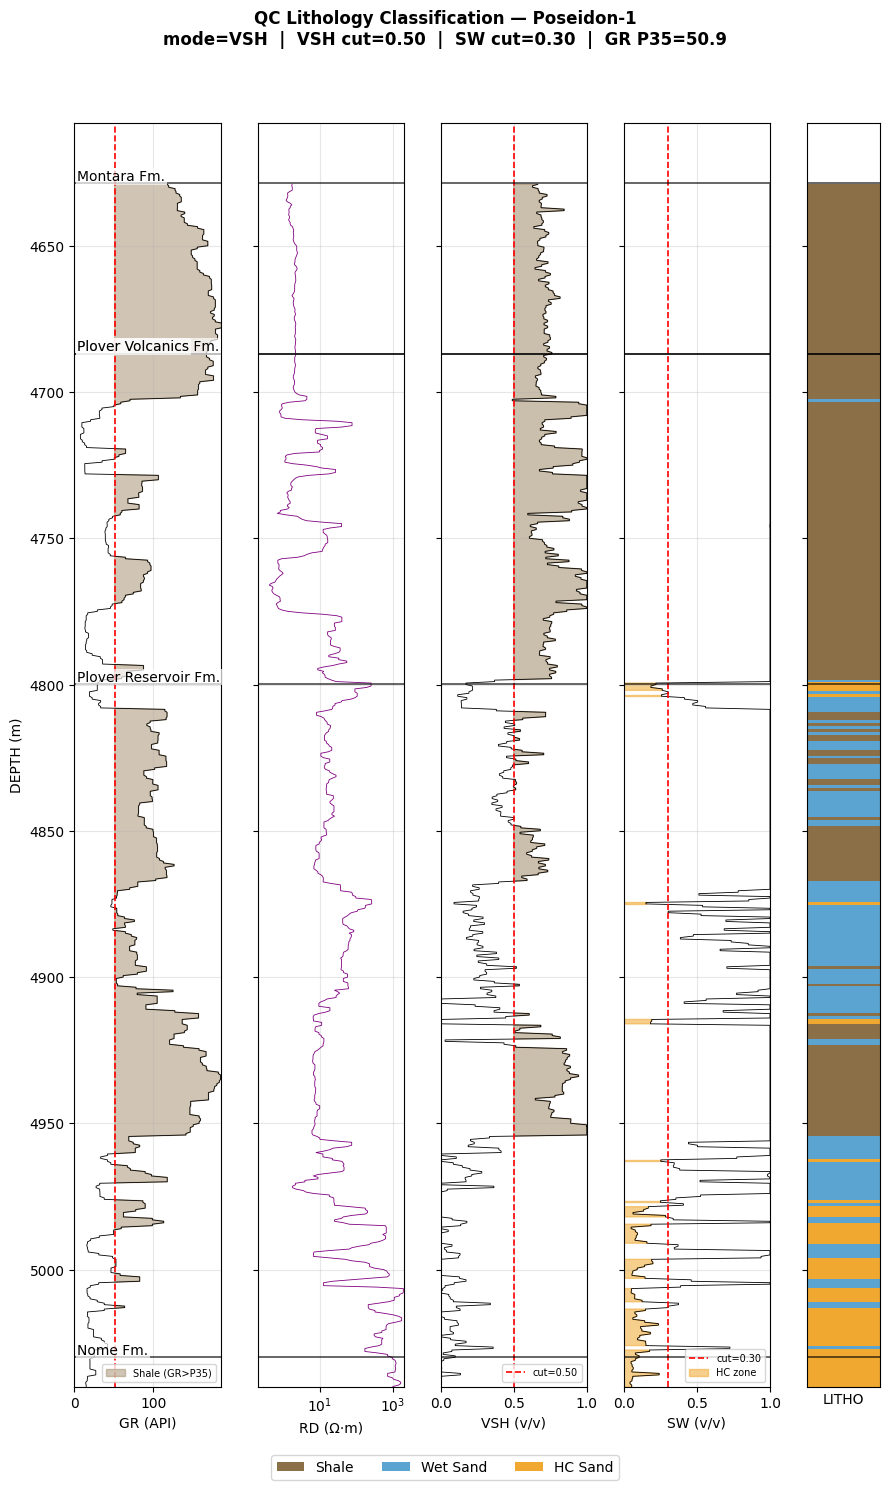

  [Boreas-1]  mode=VSH    Shale=  114  WetSand=  688  HCSand=  266


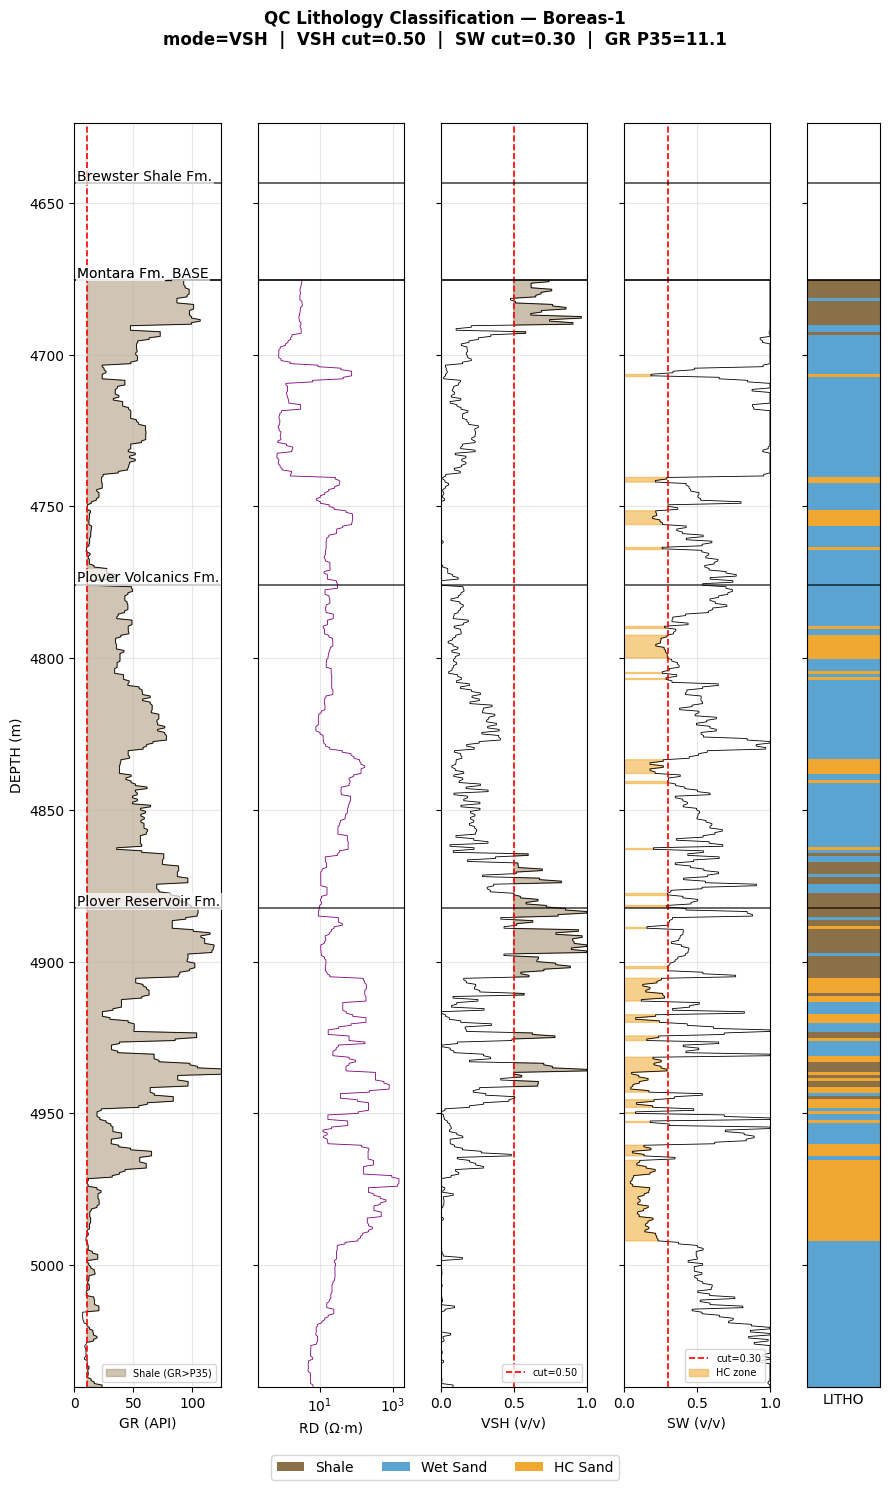

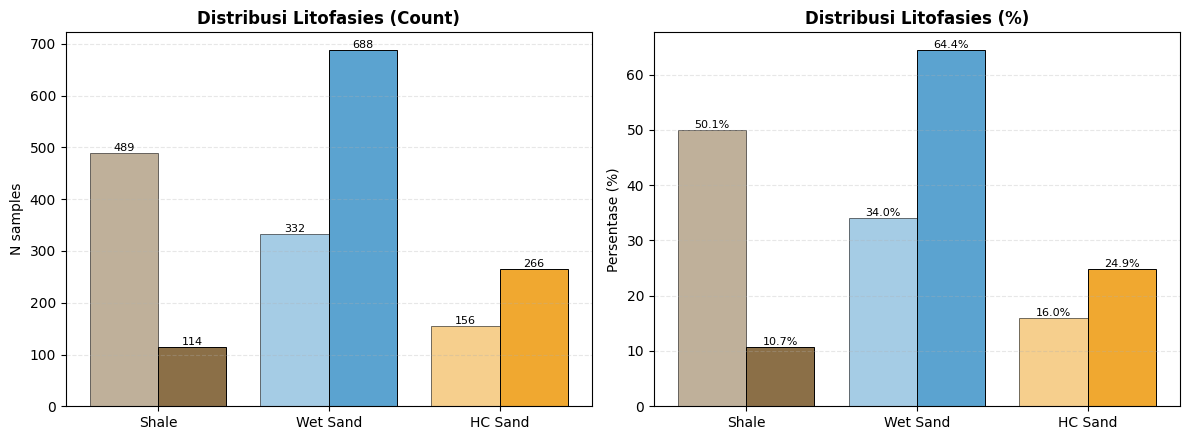


  ✓ Litho classification + QC plots done


In [14]:
from litho_qc import run_litho_qc_pipeline

# zoom ke interval Plover Volcanics → Nome saja agar QC fokus
DEPTH_ZOOM = (4625, 5040)   # Poseidon-1; sesuaikan untuk Boreas-1 bila perlu

litho_summary = run_litho_qc_pipeline(
    WELL_DFRAMES, CFG,
    WELL_TOPS=WELL_TOPS,
    depth_range=DEPTH_ZOOM,         # None = plot full log
    save_dir="./pipeline_data/02_well_cond"   # PNG otomatis tersimpan
)

## Cell 3 — Joint GMM training (P2 hybrid + P9)

**Hybrid initialization (P2 A+B):**
1. **Step B (init)**: Hitung mean per LITHO rule-based → seed `means_init` GMM
2. **Step A (post-fit)**: Auto-permute komponen agar urutan = [Shale, WetSand, HCSand]
3. **Verify**: Print mean per komponen untuk konfirmasi visual + alarm jika urutan salah

**Training zone (P9)**: Montara → Nome (bukan hanya Plover Vol → Nome).

In [15]:
training_top  = CFG["facies_gmm"]["training_top"]
training_base = CFG["facies_gmm"]["training_base"]

JOINT_FEATURES = CFG["facies_gmm"]["features"]
N_GMM_COMPONENTS = CFG["facies_gmm"]["n_components"]

print("\n" + "=" * 72)
print(f"  JOINT GMM TRAINING (HYBRID P2 INIT + P9 ZONE)")
print(f"  Training zone : {training_top} → {training_base}")
print(f"  Features      : {JOINT_FEATURES}")
print(f"  N components  : {N_GMM_COMPONENTS}")
print("=" * 72)

train_frames = []
for wname, df in WELL_DFRAMES.items():
    tops = WELL_TOPS.get(wname, {})

    def _lookup(name):
        for key, val in tops.items():
            kk = key.replace(" Fm.", "").replace(" Fm", "").lower().strip()
            tt = name.replace(" Fm.", "").replace(" Fm", "").lower().strip()
            if kk == tt:
                return float(val)
        return None

    z_top = _lookup(training_top)
    z_bot = _lookup(training_base)

    if z_top is None or z_bot is None:
        print(f"  [SKIP] {wname}: tops {training_top}/{training_base} tidak ditemukan")
        continue

    mask = (df["DEPTH"] >= min(z_top, z_bot)) & (df["DEPTH"] <= max(z_top, z_bot))
    sub = df.loc[mask, JOINT_FEATURES + ["LITHO"]].dropna(subset=JOINT_FEATURES).copy()
    sub["WELL"] = wname

    print(f"  [{wname}] zone {z_top:.1f}–{z_bot:.1f}m | {len(sub)} valid samples")
    train_frames.append(sub)

if not train_frames:
    raise RuntimeError("Tidak ada training data untuk GMM")

TRAIN_JOINT = pd.concat(train_frames, ignore_index=True)
print(f"\n  Total training samples: {len(TRAIN_JOINT)}")
for code, label in zip([1, 2, 3], ["Shale", "Wet Sand", "HC Sand"]):
    n = (TRAIN_JOINT["LITHO"] == code).sum()
    print(f"    {label:10s} (code {code}): {n:>5}  ({n/len(TRAIN_JOINT)*100:.1f}%)")

X_joint = TRAIN_JOINT[JOINT_FEATURES].values.astype(np.float64)

# ─── P2 STEP B: class-informed initialization ───
print("\n  [STEP B] Class-informed initialization")
means_init = np.zeros((N_GMM_COMPONENTS, len(JOINT_FEATURES)))
litho_to_init_idx = {1: 0, 2: 1, 3: 2}
for litho_code, comp_idx in litho_to_init_idx.items():
    mask = TRAIN_JOINT["LITHO"].values == litho_code
    if mask.sum() > 0:
        means_init[comp_idx] = X_joint[mask].mean(axis=0)
        print(f"    init means k={comp_idx} ({['Shale','WetSand','HCSand'][comp_idx]:8s}): "
              f"{means_init[comp_idx].round(3)}")
    else:
        means_init[comp_idx] = X_joint.mean(axis=0)

# ─── Fit GMM ───
SHARED_GMM = GaussianMixture(
    n_components=N_GMM_COMPONENTS,
    covariance_type="full",
    means_init=means_init,
    max_iter=1000,
    n_init=1,
    random_state=42,
    reg_covar=1e-3,
)
SHARED_GMM.fit(X_joint)

print(f"\n  GMM fit  →  converged={SHARED_GMM.converged_}  iter={SHARED_GMM.n_iter_}")
print(f"  Weights : {SHARED_GMM.weights_.round(3)}")
print(f"  Component means BEFORE permutation:")
for k in range(N_GMM_COMPONENTS):
    vsh_v = SHARED_GMM.means_[k][JOINT_FEATURES.index("VSH")]
    sw_v  = SHARED_GMM.means_[k][JOINT_FEATURES.index("SW")]
    print(f"    k={k}: VSH={vsh_v:.2f} SW={sw_v:.2f}")

# ─── P2 STEP A: auto-permute ───
print("\n  [STEP A] Auto-permute komponen → [Shale, WetSand, HCSand]")
perm = inversion_utils.auto_permute_gmm(
    SHARED_GMM, JOINT_FEATURES,
    target_order=["Shale", "Wet Sand", "HC Sand"]
)
print(f"    Permutation: {perm}")

SHARED_GMM = inversion_utils.apply_permutation_to_gmm(SHARED_GMM, perm)

# ─── Verify ───
print(f"\n  [VERIFY] Component means AFTER permutation:")
print(f"  {'k':<3} {'Label':<10} {'PHIE':>6} {'VSH':>6} {'SW':>6} {'VP':>8} {'VS':>8}")
print(f"  " + "-" * 60)
expected_labels = ["Shale", "Wet Sand", "HC Sand"]
for k in range(N_GMM_COMPONENTS):
    means_k = SHARED_GMM.means_[k]
    print(f"  {k:<3} {expected_labels[k]:<10} "
          f"{means_k[JOINT_FEATURES.index('PHIE')]:>6.3f} "
          f"{means_k[JOINT_FEATURES.index('VSH')]:>6.3f} "
          f"{means_k[JOINT_FEATURES.index('SW')]:>6.3f} "
          f"{means_k[JOINT_FEATURES.index('VP')]:>8.0f} "
          f"{means_k[JOINT_FEATURES.index('VS')]:>8.0f} ")

shale_vsh   = SHARED_GMM.means_[0][JOINT_FEATURES.index("VSH")]
wetsand_vsh = SHARED_GMM.means_[1][JOINT_FEATURES.index("VSH")]
hcsand_vsh  = SHARED_GMM.means_[2][JOINT_FEATURES.index("VSH")]
hcsand_sw   = SHARED_GMM.means_[2][JOINT_FEATURES.index("SW")]
wetsand_sw  = SHARED_GMM.means_[1][JOINT_FEATURES.index("SW")]

if not (shale_vsh > wetsand_vsh and shale_vsh > hcsand_vsh):
    print(f"\n  [WARN] Shale VSH ({shale_vsh:.2f}) bukan tertinggi!")
if not (hcsand_sw < wetsand_sw):
    print(f"  [WARN] HC Sand SW ({hcsand_sw:.2f}) tidak < WetSand SW ({wetsand_sw:.2f})")
else:
    print(f"\n  [OK] Component ordering verified: Shale ≻ WetSand ≻ HCSand")



  JOINT GMM TRAINING (HYBRID P2 INIT + P9 ZONE)
  Training zone : Plover Volcanics Fm. → Nome Fm.
  Features      : ['PHIE', 'VSH', 'SW', 'VP', 'VS', 'RHOB', 'LR', 'MR', 'RD']
  N components  : 3
  [Poseidon-1] zone 4686.9–5030.0m | 687 valid samples
  [Boreas-1] zone 4775.9–5073.6m | 596 valid samples

  Total training samples: 1283
    Shale      (code 1):   451  (35.2%)
    Wet Sand   (code 2):   592  (46.1%)
    HC Sand    (code 3):   240  (18.7%)

  [STEP B] Class-informed initialization
    init means k=0 (Shale   ): [3.90000000e-02 7.60000000e-01 8.87000000e-01 4.21045300e+03
 2.29284500e+03 2.53300000e+00 4.69531888e+07 3.47562219e+07
 2.05320000e+01]
    init means k=1 (WetSand ): [9.20000000e-02 1.68000000e-01 7.32000000e-01 4.52726400e+03
 2.94052000e+03 2.46500000e+00 1.80874513e+07 5.40674179e+07
 3.25310000e+01]
    init means k=2 (HCSand  ): [1.22000000e-01 1.02000000e-01 1.62000000e-01 4.13684000e+03
 2.75295400e+03 2.37100000e+00 1.05511230e+07 4.51041994e+07
 3.72360

## Cell 4 — GMM diagnostic (LDA + confusion matrix + PCA)

Validasi cluster separability.

  LDA score (separability): 95.6%
  [EXCELLENT] Well-separated facies

  Confusion matrix (rows=rule-based, cols=GMM prediction):
                 Shale_pred   Wet_pred    HC_pred
  Shale_true            417         26          8
  Wet_true                0        506         86
  HC_true                 0         12        228

  Classification report:
              precision    recall  f1-score   support

       Shale       1.00      0.92      0.96       451
    Wet Sand       0.93      0.85      0.89       592
     HC Sand       0.71      0.95      0.81       240

    accuracy                           0.90      1283
   macro avg       0.88      0.91      0.89      1283
weighted avg       0.91      0.90      0.90      1283



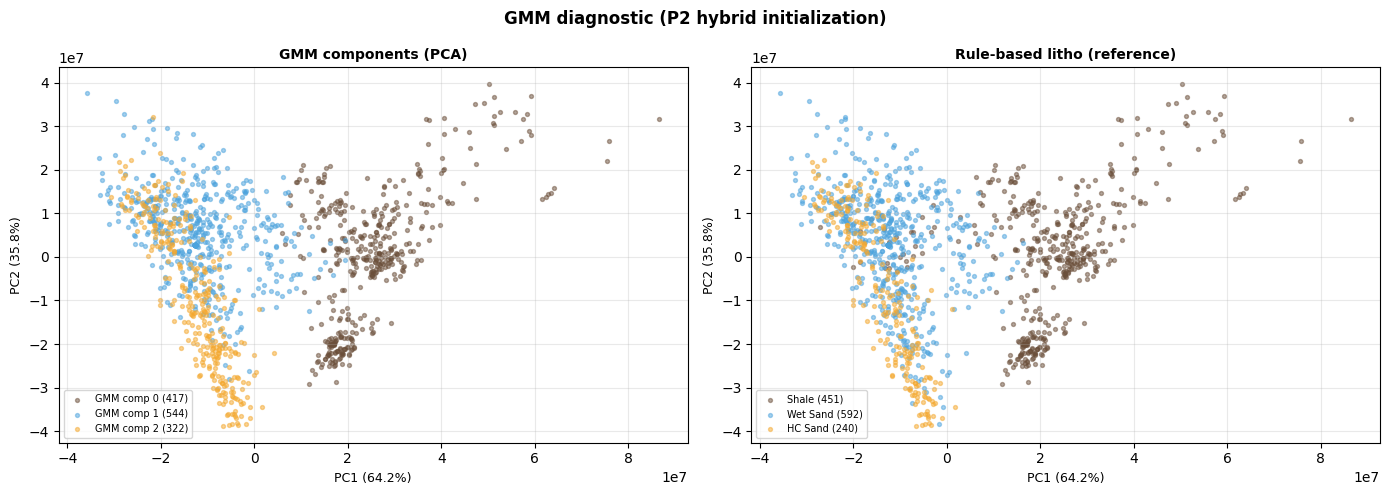


  ✓ GMM diagnostic complete


In [16]:
# ─── LDA score ───
y_litho = TRAIN_JOINT["LITHO"].values
lda = LinearDiscriminantAnalysis()
lda.fit(X_joint, y_litho)
lda_score = float(lda.score(X_joint, y_litho))

print(f"  LDA score (separability): {lda_score*100:.1f}%")
if lda_score < 0.70:
    print("  [WARN] LDA < 70% — facies sulit dipisahkan")
elif lda_score < 0.85:
    print("  [OK] Moderate separability")
else:
    print("  [EXCELLENT] Well-separated facies")

# ─── GMM prediction vs rule-based ───
y_gmm = SHARED_GMM.predict(X_joint) + 1

print(f"\n  Confusion matrix (rows=rule-based, cols=GMM prediction):")
cm = confusion_matrix(y_litho, y_gmm, labels=[1, 2, 3])
print(f"  {'':12s} {'Shale_pred':>12s} {'Wet_pred':>10s} {'HC_pred':>10s}")
for i, lbl in enumerate(["Shale_true", "Wet_true", "HC_true"]):
    print(f"  {lbl:<12s} {cm[i,0]:>12d} {cm[i,1]:>10d} {cm[i,2]:>10d}")

print(f"\n  Classification report:")
print(classification_report(y_litho, y_gmm,
                             labels=[1,2,3],
                             target_names=["Shale", "Wet Sand", "HC Sand"],
                             zero_division=0))

plot_utils.plot_gmm_diagnostic(
    X_joint, JOINT_FEATURES, SHARED_GMM,
    litho_labels=y_litho,
    title="GMM diagnostic (P2 hybrid initialization)"
)

GMM_DIAGNOSTICS = {
    "lda_score": lda_score,
    "training_zone": f"{training_top} → {training_base}",
    "n_train": int(len(TRAIN_JOINT)),
    "confusion_matrix": cm.tolist(),
    "permutation": perm,
    "weights": SHARED_GMM.weights_.tolist(),
    "converged": bool(SHARED_GMM.converged_),
    "n_iter": int(SHARED_GMM.n_iter_),
    "rule_based_distribution": litho_summary,
}
print("\n  ✓ GMM diagnostic complete")

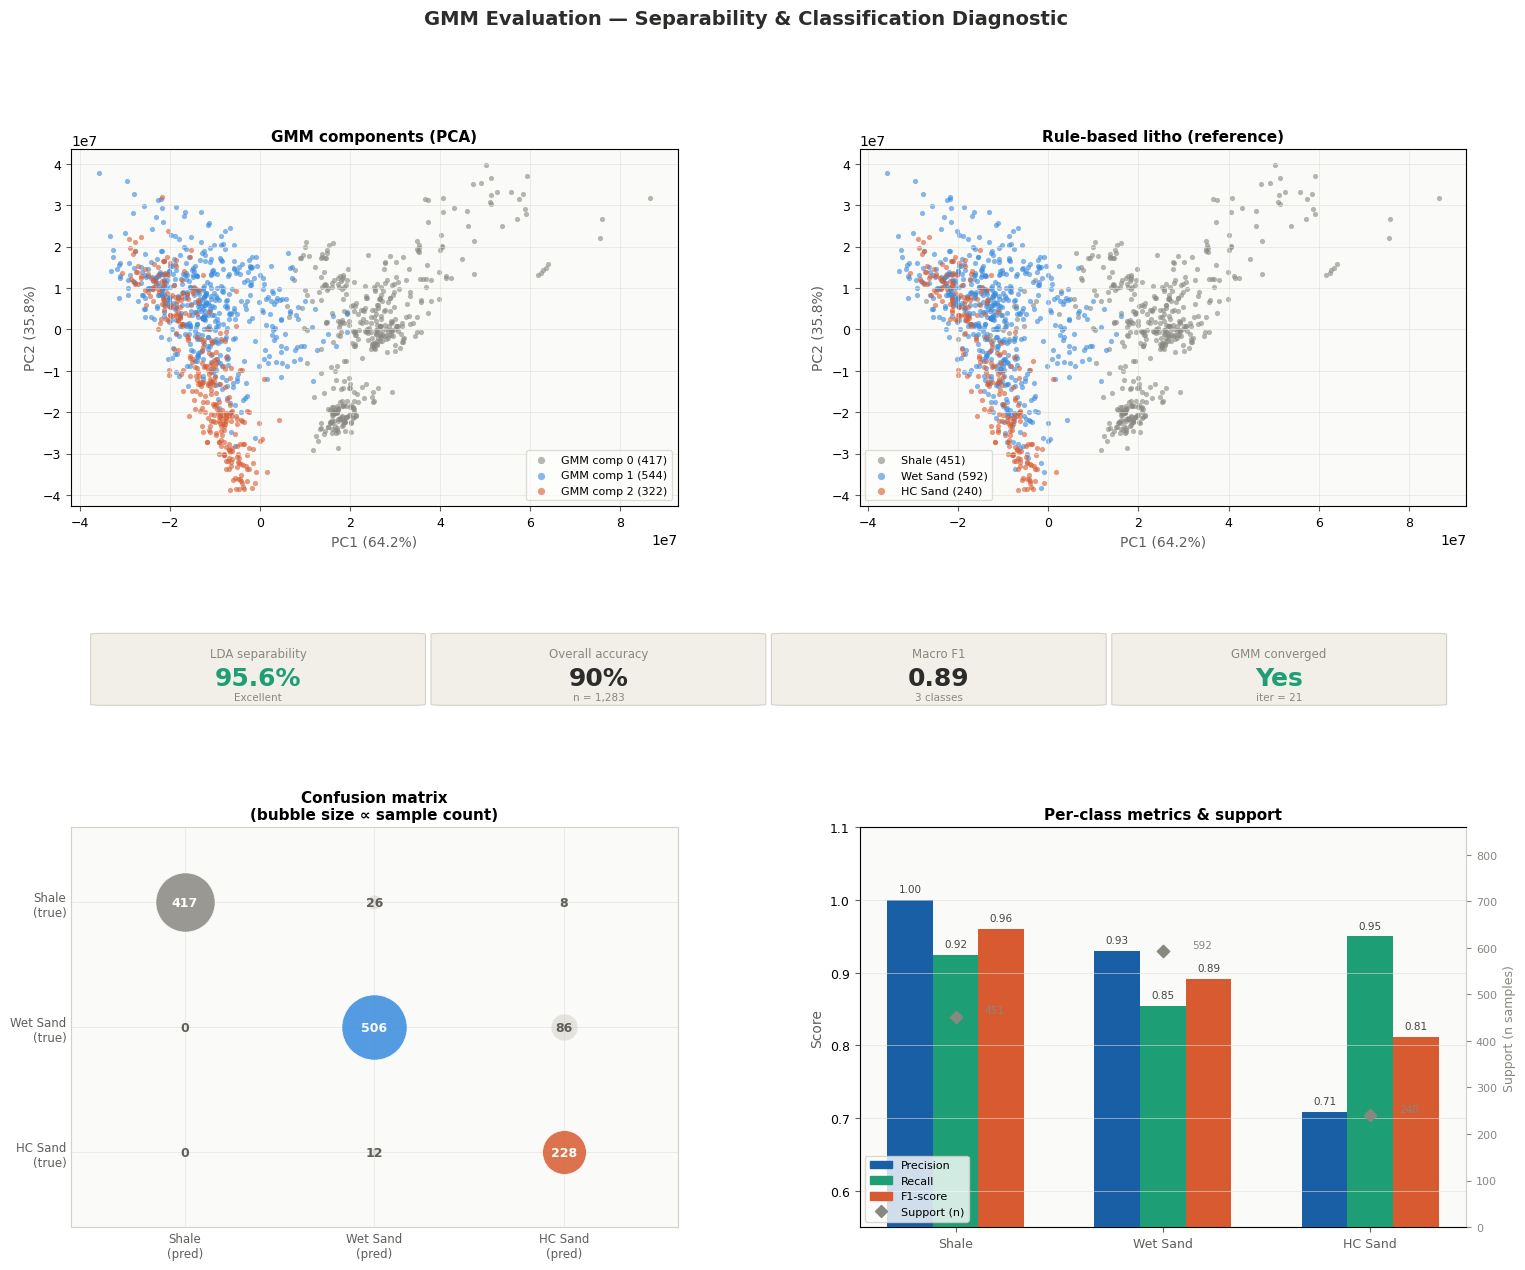

In [17]:
"""
plot_gmm_evaluation.py
──────────────────────
Fungsi visualisasi evaluasi GMM — lanjutan dari plot_gmm_diagnostic.
Gabungkan ke plot_utils.py atau jalankan langsung di NB2.

Dipanggil setelah blok GMM diagnostic yang sudah ada:
    plot_gmm_evaluation(
        X_joint, SHARED_GMM, y_litho, y_gmm,
        GMM_DIAGNOSTICS, JOINT_FEATURES
    )
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")


# ── Palet warna konsisten dengan plot_utils pipeline ──────────────────────────
LITHO_COLORS = {
    1: "#888780",   # Shale   — abu-abu
    2: "#378ADD",   # Wet Sand — biru
    3: "#D85A30",   # HC Sand  — oranye-merah
}
LITHO_LABELS = {1: "Shale", 2: "Wet Sand", 3: "HC Sand"}
COMP_COLORS  = {0: "#888780", 1: "#378ADD", 2: "#D85A30"}
COMP_LABELS  = {0: "GMM comp 0", 1: "GMM comp 1", 2: "GMM comp 2"}


def plot_gmm_evaluation(
    X_joint,
    gmm,
    y_litho,
    y_gmm,
    gmm_diagnostics,
    joint_features=None,
    figsize=(18, 14),
    save_path=None,
    dpi=150,
):
    """
    Visualisasi evaluasi GMM dalam satu figure 5-panel:

        [A] PCA — GMM components    [B] PCA — Rule-based litho
        [C] Metric summary cards
        [D] Confusion matrix         [E] Per-class metrics + support

    Parameters
    ----------
    X_joint        : np.ndarray  (n, d)  — fitur GMM training (post-FRM)
    gmm            : GaussianMixture     — model GMM terlatih (SHARED_GMM)
    y_litho        : np.ndarray (n,)     — label rule-based (int 1/2/3)
    y_gmm          : np.ndarray (n,)     — prediksi GMM     (int 1/2/3)
    gmm_diagnostics: dict                — GMM_DIAGNOSTICS dari NB2
    joint_features : list[str] | None    — nama fitur (opsional, untuk label)
    figsize        : tuple
    save_path      : str | None          — jika diisi, simpan figure ke path ini
    dpi            : int
    """

    # ── 0. PCA 2-komponen ─────────────────────────────────────────────────────
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_joint)
    pc1_var = pca.explained_variance_ratio_[0] * 100
    pc2_var = pca.explained_variance_ratio_[1] * 100

    # GMM component index (0-based), sesuaikan label agar cocok rule-based
    gmm_comp = gmm.predict(X_joint)          # 0/1/2
    gmm_pred_mapped = y_gmm                  # sudah di-map ke 1/2/3 oleh NB2

    # ── 1. Parse diagnostics ───────────────────────────────────────────────────
    lda_score = gmm_diagnostics.get("lda_score", None)
    cm        = np.array(gmm_diagnostics.get("confusion_matrix", [[0,0,0]]*3))
    n_train   = gmm_diagnostics.get("n_train", len(X_joint))
    converged = gmm_diagnostics.get("converged", True)
    n_iter    = gmm_diagnostics.get("n_iter", "—")

    rep = classification_report(
        y_litho, gmm_pred_mapped,
        labels=[1, 2, 3],
        target_names=["Shale", "Wet Sand", "HC Sand"],
        output_dict=True,
        zero_division=0,
    )
    classes    = ["Shale", "Wet Sand", "HC Sand"]
    precision  = [rep[c]["precision"]  for c in classes]
    recall     = [rep[c]["recall"]     for c in classes]
    f1         = [rep[c]["f1-score"]   for c in classes]
    support    = [rep[c]["support"]    for c in classes]
    accuracy   = rep["accuracy"]
    macro_f1   = rep["macro avg"]["f1-score"]

    # ── 2. Layout ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, facecolor="white")
    fig.suptitle(
        "GMM Evaluation — Separability & Classification Diagnostic",
        fontsize=14, fontweight="bold", y=0.98, color="#2C2C2A"
    )

    # GridSpec: baris 0 → PCA pair, baris 1 → metric cards, baris 2 → cm + metrics
    gs = gridspec.GridSpec(
        3, 2,
        figure=fig,
        height_ratios=[2.5, 0.6, 2.8],
        hspace=0.42, wspace=0.30,
    )
    ax_pca_gmm  = fig.add_subplot(gs[0, 0])
    ax_pca_rule = fig.add_subplot(gs[0, 1])
    ax_cards    = fig.add_subplot(gs[1, :])
    ax_cm       = fig.add_subplot(gs[2, 0])
    ax_metrics  = fig.add_subplot(gs[2, 1])

    TICK_STYLE = dict(labelsize=9, color="#5F5E5A")
    LABEL_STYLE = dict(fontsize=10, color="#5F5E5A")

    # ─────────────────────────────────────────────────────────────────────────
    # Panel A — PCA: GMM components
    # ─────────────────────────────────────────────────────────────────────────
    for comp_idx in [0, 1, 2]:
        mask = gmm_comp == comp_idx
        litho_key = comp_idx + 1           # 0→1, 1→2, 2→3
        n = mask.sum()
        ax_pca_gmm.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=COMP_COLORS[comp_idx], s=14, alpha=0.6,
            linewidths=0, rasterized=True,
            label=f"{COMP_LABELS[comp_idx]} ({n})",
        )

    ax_pca_gmm.set_xlabel(f"PC1 ({pc1_var:.1f}%)", **LABEL_STYLE)
    ax_pca_gmm.set_ylabel(f"PC2 ({pc2_var:.1f}%)", **LABEL_STYLE)
    ax_pca_gmm.set_title("GMM components (PCA)", fontsize=11, fontweight="bold", pad=6)
    ax_pca_gmm.tick_params(**TICK_STYLE)
    ax_pca_gmm.legend(fontsize=8, markerscale=1.4, framealpha=0.7, edgecolor="#D3D1C7")
    ax_pca_gmm.set_facecolor("#FAFAF8")
    ax_pca_gmm.grid(True, lw=0.4, color="#E0DED7", zorder=0)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel B — PCA: Rule-based litho
    # ─────────────────────────────────────────────────────────────────────────
    for litho_key in [1, 2, 3]:
        mask = y_litho == litho_key
        n = mask.sum()
        ax_pca_rule.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=LITHO_COLORS[litho_key], s=14, alpha=0.6,
            linewidths=0, rasterized=True,
            label=f"{LITHO_LABELS[litho_key]} ({n})",
        )

    ax_pca_rule.set_xlabel(f"PC1 ({pc1_var:.1f}%)", **LABEL_STYLE)
    ax_pca_rule.set_ylabel(f"PC2 ({pc2_var:.1f}%)", **LABEL_STYLE)
    ax_pca_rule.set_title("Rule-based litho (reference)", fontsize=11, fontweight="bold", pad=6)
    ax_pca_rule.tick_params(**TICK_STYLE)
    ax_pca_rule.legend(fontsize=8, markerscale=1.4, framealpha=0.7, edgecolor="#D3D1C7")
    ax_pca_rule.set_facecolor("#FAFAF8")
    ax_pca_rule.grid(True, lw=0.4, color="#E0DED7", zorder=0)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel C — Metric cards (text, no axes)
    # ─────────────────────────────────────────────────────────────────────────
    ax_cards.axis("off")

    def draw_card(ax, x, y, w, h, title, value, subtitle, val_color="#2C2C2A"):
        bg = mpatches.FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.01",
            facecolor="#F1EFE8", edgecolor="#D3D1C7", linewidth=0.8,
            transform=ax.transAxes, clip_on=False,
        )
        ax.add_patch(bg)
        ax.text(x + w/2, y + h*0.72, title,
                ha="center", va="center", fontsize=8.5,
                color="#888780", transform=ax.transAxes)
        ax.text(x + w/2, y + h*0.38, value,
                ha="center", va="center", fontsize=18, fontweight="bold",
                color=val_color, transform=ax.transAxes)
        ax.text(x + w/2, y + h*0.10, subtitle,
                ha="center", va="center", fontsize=7.5,
                color="#888780", transform=ax.transAxes)

    lda_color = "#1D9E75" if lda_score >= 0.85 else ("#D85A30" if lda_score < 0.70 else "#BA7517")
    lda_label = "Excellent" if lda_score >= 0.85 else ("Moderate" if lda_score >= 0.70 else "Poor")

    card_w, card_h = 0.22, 0.82
    gap = (1 - 4 * card_w) / 5
    for i, (title, val, sub, col) in enumerate([
        ("LDA separability",   f"{lda_score*100:.1f}%",      lda_label,          lda_color),
        ("Overall accuracy",   f"{accuracy*100:.0f}%",        f"n = {n_train:,}", "#2C2C2A"),
        ("Macro F1",           f"{macro_f1:.2f}",             "3 classes",        "#2C2C2A"),
        ("GMM converged",      "Yes" if converged else "No",  f"iter = {n_iter}", "#1D9E75" if converged else "#D85A30"),
    ]):
        x = gap + i * (card_w + gap)
        draw_card(ax_cards, x, 0.06, card_w, card_h, title, val, sub, col)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel D — Confusion matrix (bubble)
    # ─────────────────────────────────────────────────────────────────────────
    max_count = cm.max()
    scale     = 2200 / max_count

    for r in range(3):
        for c in range(3):
            val  = cm[r, c]
            size = val * scale
            color = LITHO_COLORS[r + 1] if r == c else "#D3D1C7"
            alpha = 0.85 if r == c else 0.55

            ax_cm.scatter(c, 2 - r, s=size, c=color, alpha=alpha,
                          linewidths=0.5, edgecolors="white", zorder=3)
            ax_cm.text(c, 2 - r, str(val),
                       ha="center", va="center", fontsize=9, fontweight="bold",
                       color="white" if r == c else "#5F5E5A", zorder=4)

    ax_cm.set_xticks([0, 1, 2])
    ax_cm.set_xticklabels(["Shale\n(pred)", "Wet Sand\n(pred)", "HC Sand\n(pred)"],
                           fontsize=8.5, color="#5F5E5A")
    ax_cm.set_yticks([0, 1, 2])
    ax_cm.set_yticklabels(["HC Sand\n(true)", "Wet Sand\n(true)", "Shale\n(true)"],
                           fontsize=8.5, color="#5F5E5A")
    ax_cm.set_xlim(-0.6, 2.6)
    ax_cm.set_ylim(-0.6, 2.6)
    ax_cm.set_title("Confusion matrix\n(bubble size ∝ sample count)",
                     fontsize=11, fontweight="bold", pad=6)
    ax_cm.set_facecolor("#FAFAF8")
    ax_cm.grid(True, lw=0.4, color="#E0DED7", zorder=0)
    ax_cm.tick_params(length=0)
    for sp in ax_cm.spines.values():
        sp.set_edgecolor("#D3D1C7")

    # ─────────────────────────────────────────────────────────────────────────
    # Panel E — Per-class metrics (grouped bar) + support (right y-axis)
    # ─────────────────────────────────────────────────────────────────────────
    x     = np.arange(len(classes))
    width = 0.22
    bar_kw = dict(linewidth=0)

    ax_metrics.bar(x - width, precision, width, label="Precision", color="#185FA5", **bar_kw)
    ax_metrics.bar(x,         recall,    width, label="Recall",    color="#1D9E75", **bar_kw)
    ax_metrics.bar(x + width, f1,        width, label="F1-score",  color="#D85A30", **bar_kw)

    for bars, vals in zip(
        [x - width, x, x + width],
        [precision, recall, f1],
    ):
        for xi, v in zip(bars, vals):
            ax_metrics.text(xi, v + 0.008, f"{v:.2f}",
                            ha="center", va="bottom", fontsize=7.5, color="#444441")

    # Support sebagai scatter di sumbu kanan
    ax_sup = ax_metrics.twinx()
    ax_sup.scatter(x, support, marker="D", s=40, color="#888780",
                   zorder=5, label="Support (n)")
    for xi, s_val in zip(x, support):
        ax_sup.text(xi + 0.14, s_val + 8, str(int(s_val)),
                    fontsize=7.5, color="#888780")
    ax_sup.set_ylabel("Support (n samples)", fontsize=9, color="#888780")
    ax_sup.tick_params(labelsize=8, colors="#888780")
    ax_sup.set_ylim(0, max(support) * 1.45)
    ax_sup.spines["right"].set_edgecolor("#D3D1C7")

    ax_metrics.set_xticks(x)
    ax_metrics.set_xticklabels(classes, fontsize=9, color="#5F5E5A")
    ax_metrics.set_ylim(0.55, 1.10)
    ax_metrics.set_ylabel("Score", **LABEL_STYLE)
    ax_metrics.set_title("Per-class metrics & support",
                          fontsize=11, fontweight="bold", pad=6)
    ax_metrics.set_facecolor("#FAFAF8")
    ax_metrics.grid(True, axis="y", lw=0.4, color="#E0DED7", zorder=0)
    ax_metrics.tick_params(**TICK_STYLE)
    for sp in ax_metrics.spines.values():
        sp.set_edgecolor("#D3D1C7")

    # Legend gabungan panel E
    handles_bar = [
        mpatches.Patch(color="#185FA5", label="Precision"),
        mpatches.Patch(color="#1D9E75", label="Recall"),
        mpatches.Patch(color="#D85A30", label="F1-score"),
        Line2D([0], [0], marker="D", color="#888780",
               markersize=6, linestyle="None", label="Support (n)"),
    ]
    ax_metrics.legend(handles=handles_bar, fontsize=8,
                      framealpha=0.8, edgecolor="#D3D1C7",
                      loc="lower left")

    # ── 3. Simpan / tampilkan ──────────────────────────────────────────────────
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# SNIPPET — Tempelkan langsung di NB2, setelah blok GMM diagnostic yang ada
# ══════════════════════════════════════════════════════════════════════════════

# ─── Paste kode fungsi di atas ke plot_utils.py, ATAU jalankan inline ───────

fig = plot_gmm_evaluation(
    X_joint        = X_joint,
    gmm            = SHARED_GMM,
    y_litho        = y_litho,
    y_gmm          = y_gmm,
    gmm_diagnostics= GMM_DIAGNOSTICS,
    joint_features = JOINT_FEATURES,
)

## Cell 4b — Facies comparison: Rule-based vs GMM (2-track)

Setelah GMM dilatih dan di-permute, bandingkan secara visual **klasifikasi rule-based** 
(kiri, merah) dengan **klasifikasi GMM** (kanan, biru) per sumur.

Perbedaan antara dua track menunjukkan **ambiguitas** facies — zona di mana rule-based 
dan GMM tidak sepakat adalah zona yang perlu perhatian di interpretasi.

  [Poseidon-1] Rule-based vs GMM agreement: 85.4%
  [Boreas-1] Rule-based vs GMM agreement: 84.7%


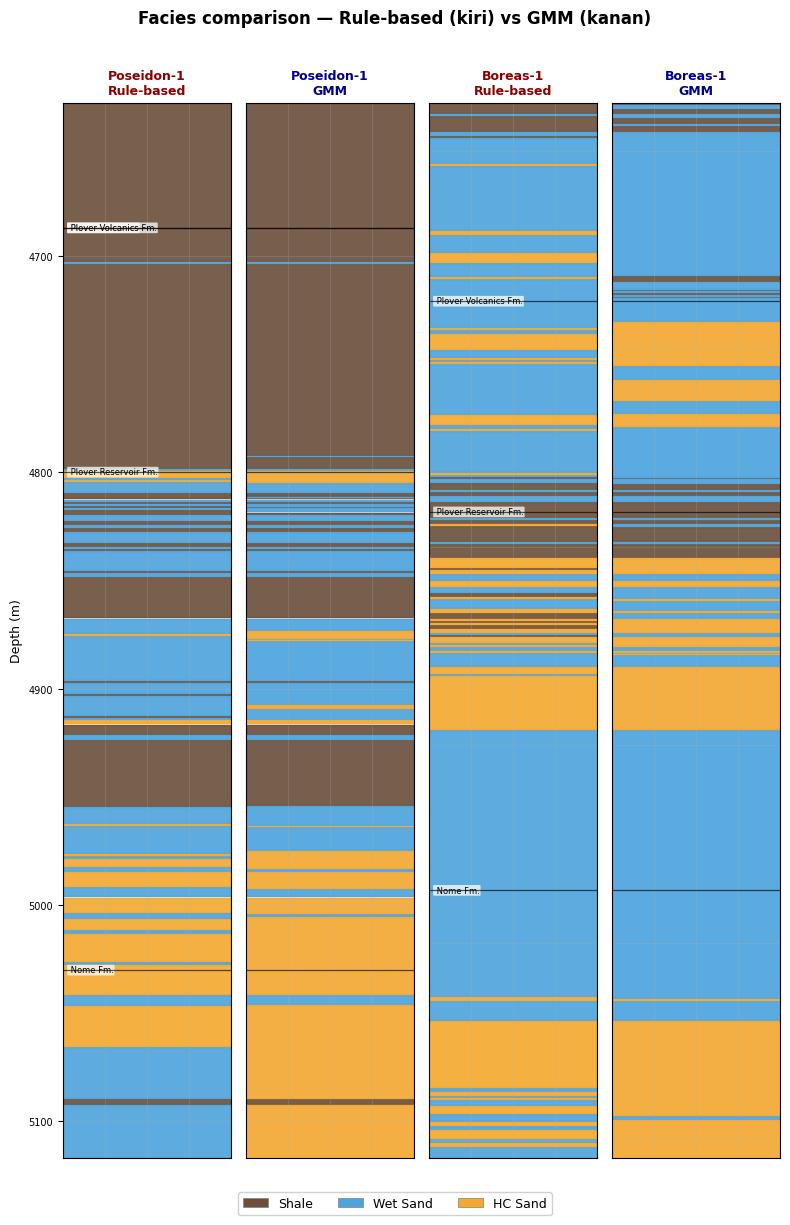


  ✓ Facies comparison plot done


In [18]:
# ─── Tambahkan kolom LITHO_GMM ke setiap DataFrame ───
for wname, df in WELL_DFRAMES.items():
    feat_filled = df[JOINT_FEATURES].fillna(df[JOINT_FEATURES].median())
    gmm_pred = SHARED_GMM.predict(feat_filled.values)
    df["LITHO_GMM"] = (gmm_pred + 1).astype(np.int8)
    WELL_DFRAMES[wname] = df

    agree = (df["LITHO_GMM"] == df["LITHO"]).mean()
    print(f"  [{wname}] Rule-based vs GMM agreement: {agree*100:.1f}%")

# ─── 2-track comparison plot ───
plot_utils.plot_facies_comparison_2track(
    WELL_DFRAMES,
    well_tops=WELL_TOPS,
    depth_col="DEPTH",
    litho_rule_col="LITHO",
    litho_gmm_col="LITHO_GMM",
    figsize=(4, 12),
    title="Facies comparison — Rule-based (kiri) vs GMM (kanan)",
)
print("\n  ✓ Facies comparison plot done")


## Cell 5 — Histogram log measured


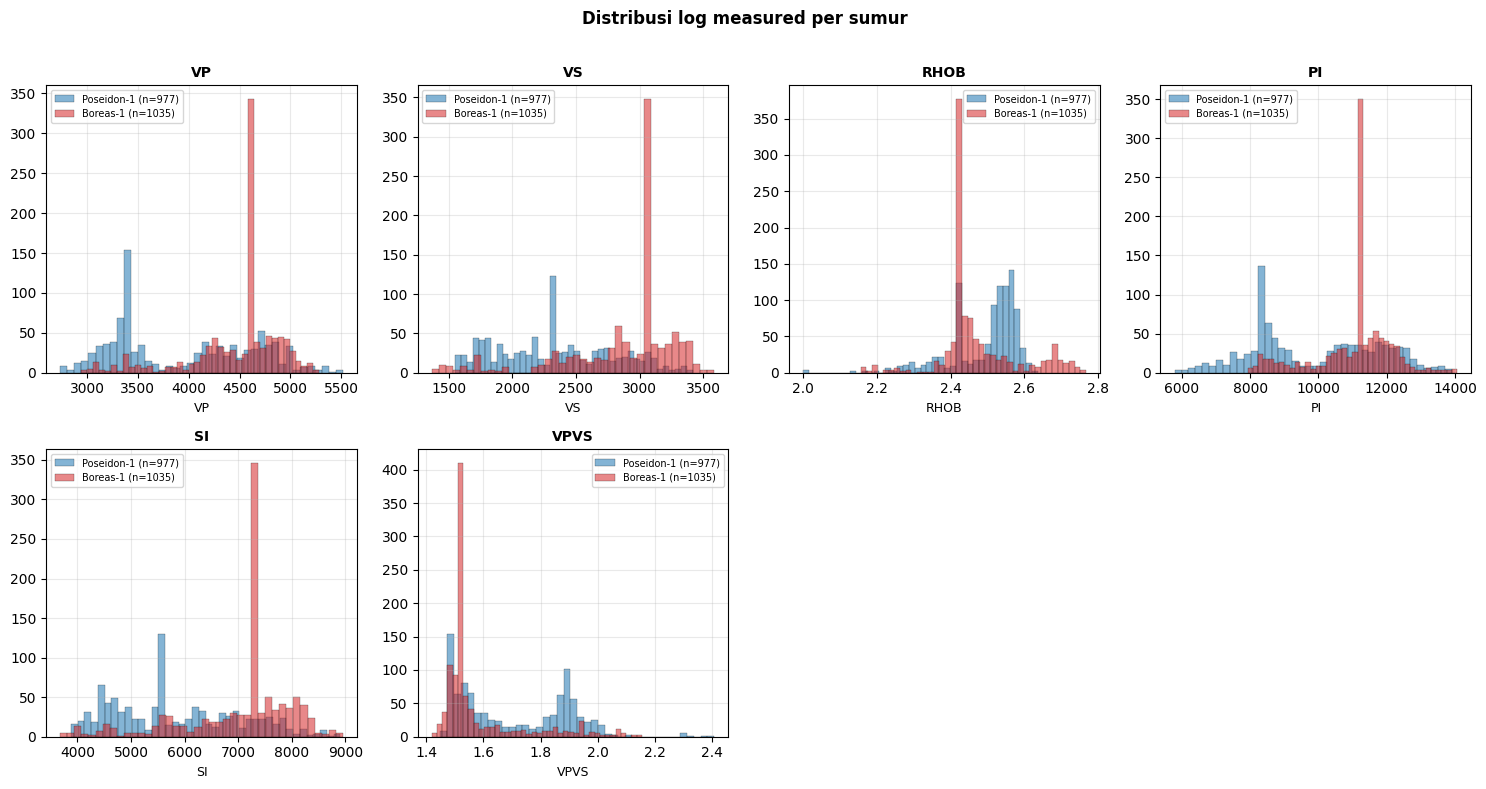

(<Figure size 1500x800 with 8 Axes>,
 array([<Axes: title={'center': 'VP'}, xlabel='VP'>,
        <Axes: title={'center': 'VS'}, xlabel='VS'>,
        <Axes: title={'center': 'RHOB'}, xlabel='RHOB'>,
        <Axes: title={'center': 'PI'}, xlabel='PI'>,
        <Axes: title={'center': 'SI'}, xlabel='SI'>,
        <Axes: title={'center': 'VPVS'}, xlabel='VPVS'>, <Axes: >,
        <Axes: >], dtype=object))

In [19]:
df_combined = pd.concat([df.assign(WELL=wid) for wid, df in WELL_DFRAMES.items()],
                        ignore_index=True)

plot_utils.plot_log_histograms(
    WELL_DFRAMES,
    cols=["VP", "VS", "RHOB", "PI", "SI", "VPVS"],
    figsize=(15, 8),
    title="Distribusi log measured per sumur"
)


## Cell 6 — Crossplots dengan RPT overlay (P14)

3 crossplot standar dengan template `plot_utils.plot_crossplot`:
1. VP vs VS — measured + RPT curves
2. AI vs Vp/Vs — gas detection
3. AI Gassmann vs Vp/Vs Gassmann — model verification

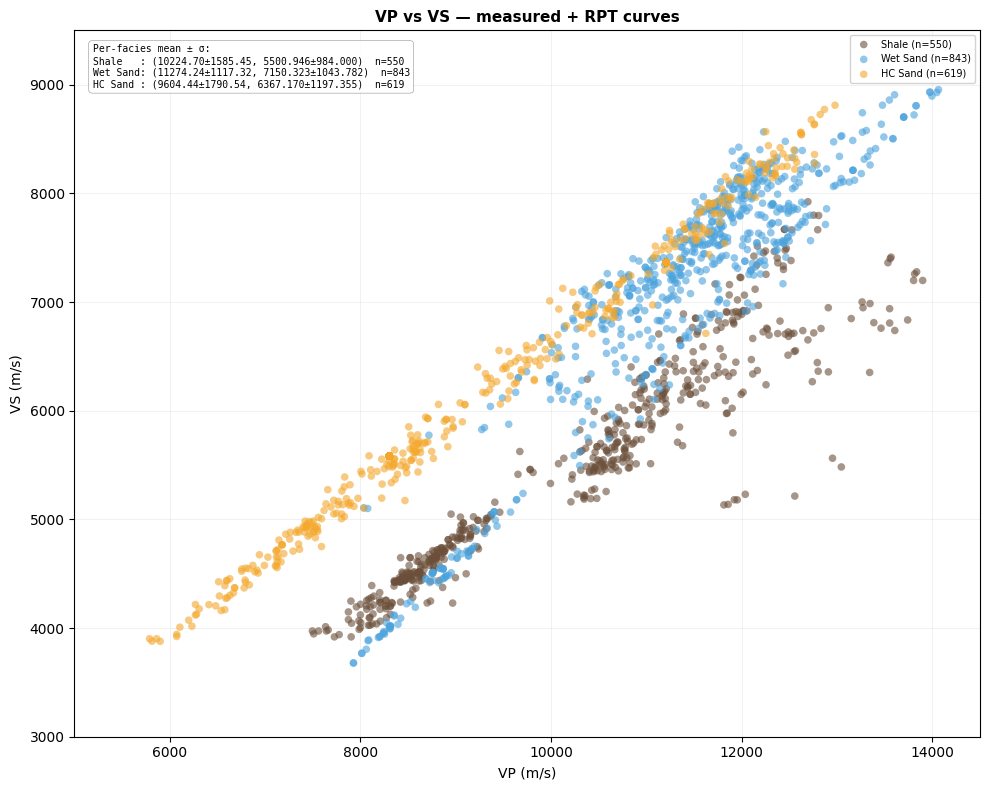

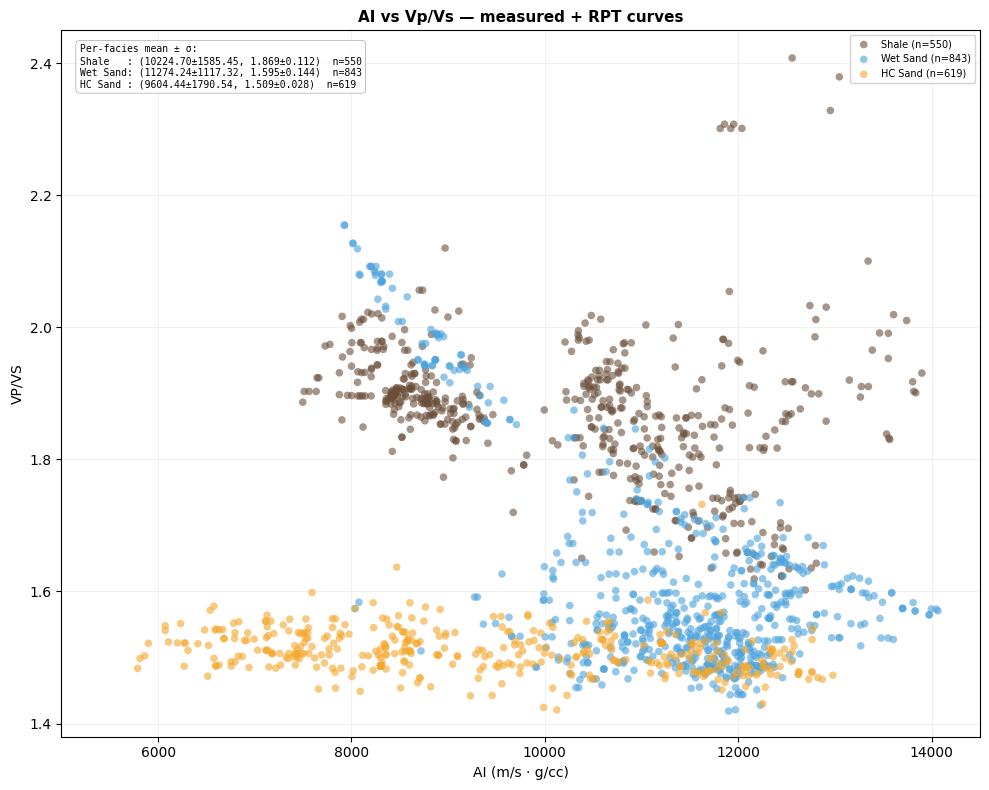

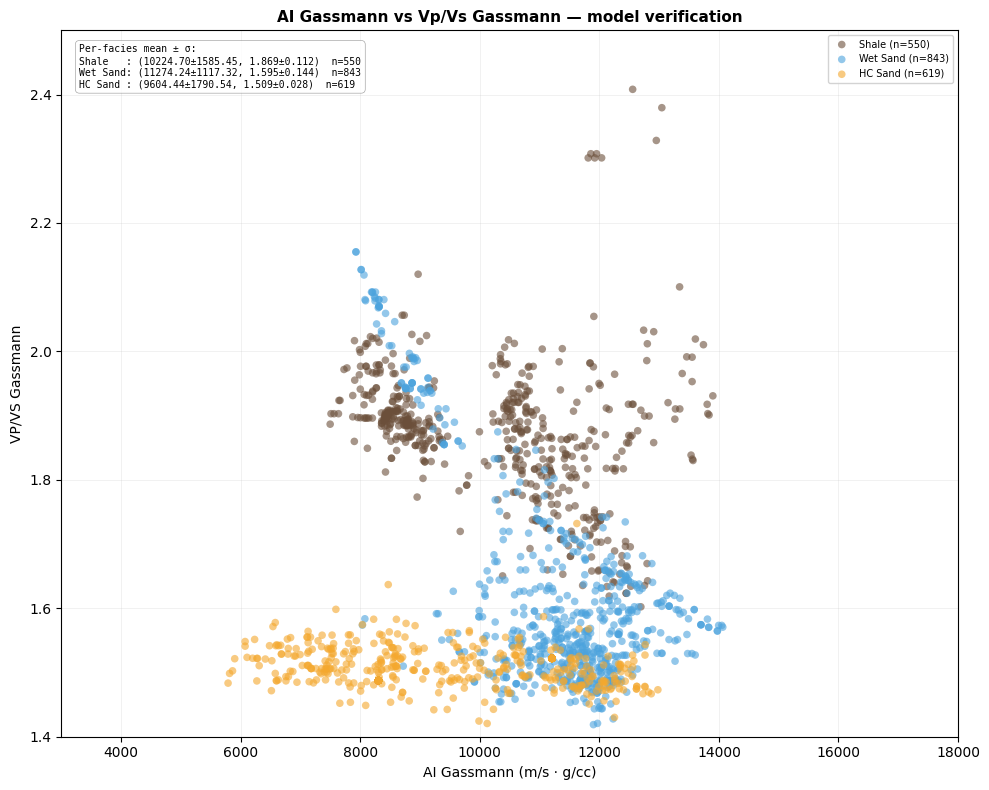

In [20]:
rp_cfg = CFG["rock_physics"]  # loaded here since RPM cell removed

# 1) VP vs VS
fig, ax = plt.subplots(figsize=(10, 8))
plot_utils.plot_crossplot(
    df_combined, x_col="PI", y_col="SI", color_by="LITHO_GMM",
    title="VP vs VS — measured + RPT curves",
    xlabel="VP (m/s)", ylabel="VS (m/s)",
    xlim=(5000, 14500), ylim=(3000, 9500),
    annotate_stats=True, ax=ax, show=False,
)
plt.tight_layout(); plt.show()

# 2) AI vs Vp/Vs
fig, ax = plt.subplots(figsize=(10, 8))
plot_utils.plot_crossplot(
    df_combined, x_col="PI", y_col="VPVS", color_by="LITHO_GMM",
    title="AI vs Vp/Vs — measured + RPT curves",
    xlabel="AI (m/s · g/cc)", ylabel="VP/VS",
    xlim=(5000, 14500), ylim=(1.38, 2.45),
    annotate_stats=True, ax=ax, show=False,
)
plt.tight_layout(); plt.show()

# 3) AI_Gassmann vs Vp/Vs_Gassmann (model)
if "PI" in df_combined.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_utils.plot_crossplot(
        df_combined, x_col="PI", y_col="VPVS", color_by="LITHO_GMM",
        title="AI Gassmann vs Vp/Vs Gassmann — model verification",
        xlabel="AI Gassmann (m/s · g/cc)", ylabel="VP/VS Gassmann",
        xlim=(3000, 18000), ylim=(1.4, 2.5),
        annotate_stats=True, ax=ax, show=False,
    )
    plt.tight_layout(); plt.show()


## Cell 6b — Sensitivity analysis: AI vs Vp/Vs | PI vs SI (tanpa RPT)

Plot **sensitivity analysis** bersih tanpa RPT curves:
- **Kiri**: AI vs Vp/Vs — diagram klasik untuk diskriminasi litofasies
- **Kanan**: PI vs SI — diagram untuk membedakan porositas dan komposisi mineral

Kedua plot menampilkan **KDE density contour**, **error bars per facies** (±1σ), 
dan **HC Sand reference lines** (P75 boundary).

> RPT curves terpisah ada di Cell 8 di atas.

## Cell 7 — 9-Track composite log dengan model overlay + LITHO

Sekarang VP_GASSMANN/VS_GASSMANN tampil sebagai dotted overlay di Track 4,
dan LITHO terisi di Track 9 dengan facies colormap.


  Plotting Poseidon-1 ...


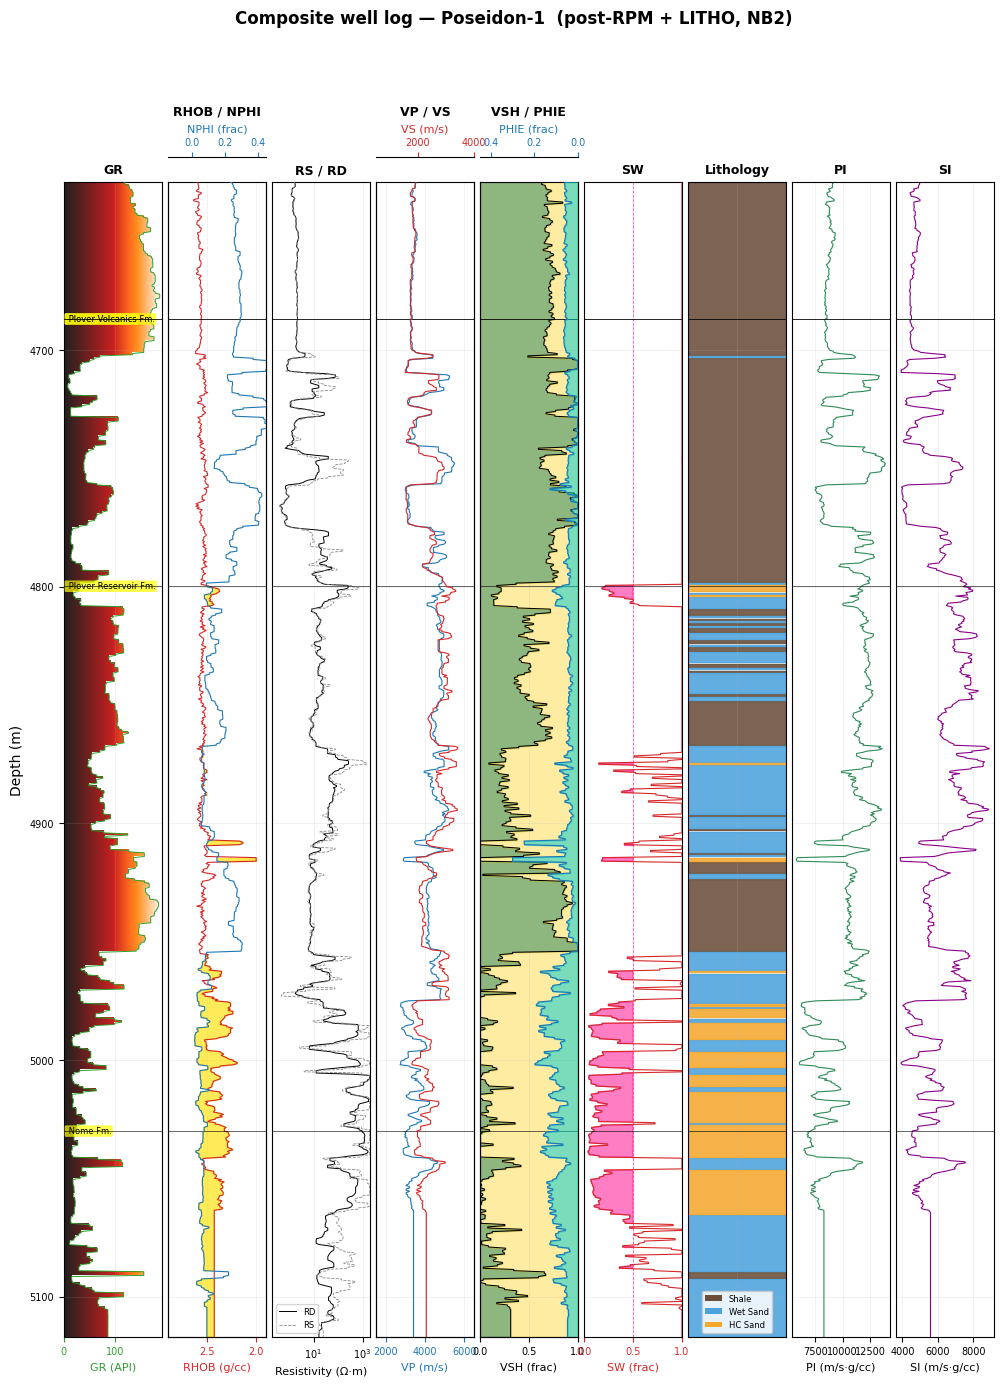


  Plotting Boreas-1 ...


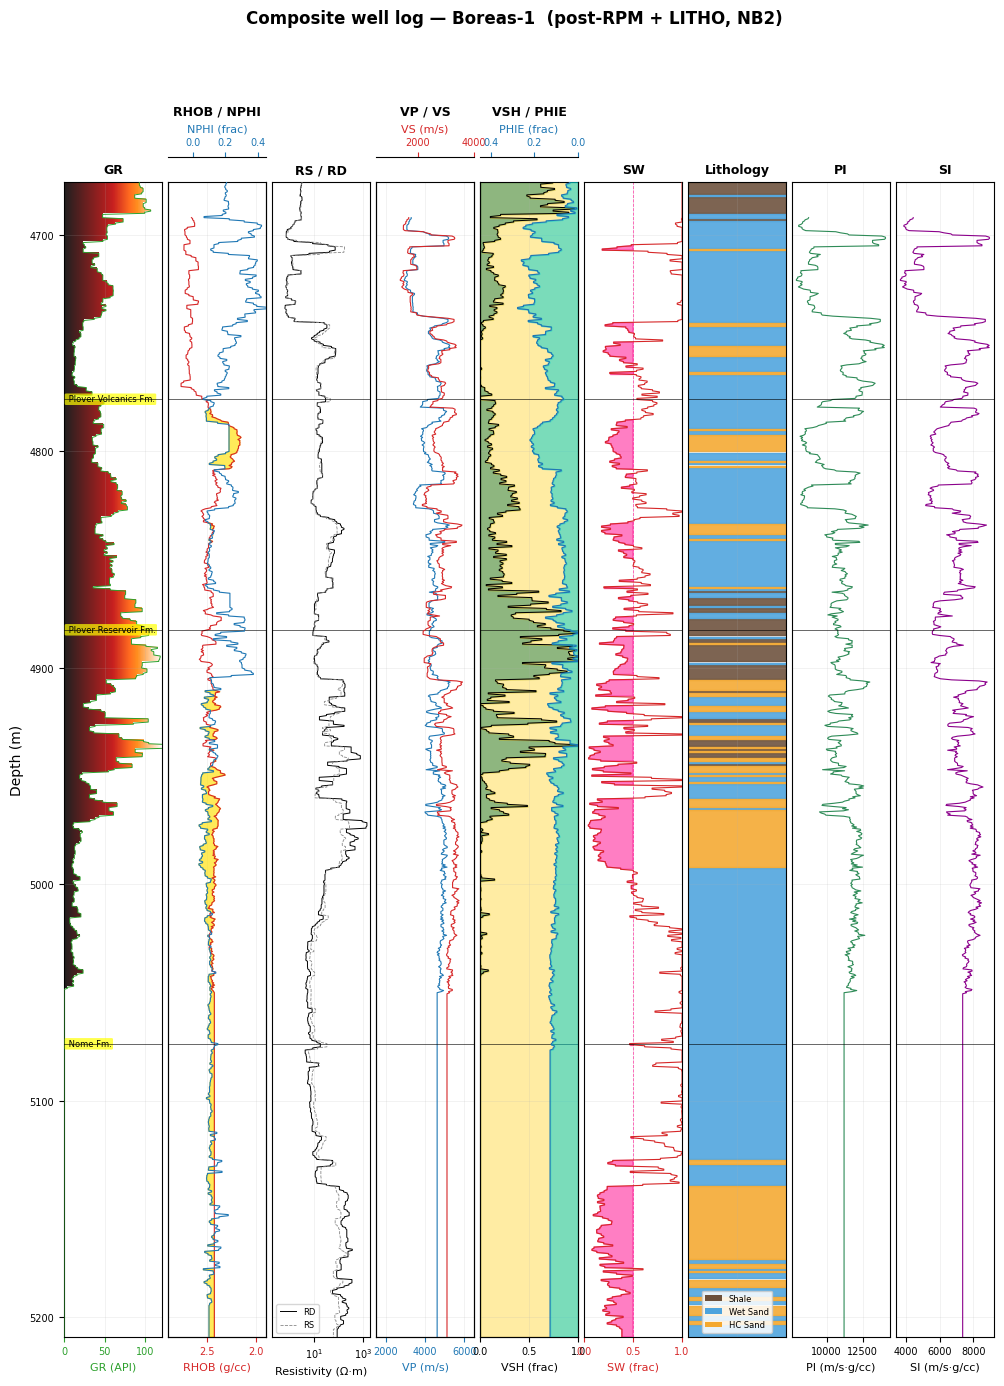

In [21]:
for well_id, df in WELL_DFRAMES.items():
    print(f"\n  Plotting {well_id} ...")
    plot_utils.plot_well_logs_9track(
        df, well_id=well_id,
        tops=WELL_TOPS.get(well_id),
        depth_col="DEPTH",
        title_suffix="  (post-RPM + LITHO, NB2)",
    )

## Cell 8 — Calibrate Σ₀ prior dari well log (P4)

Compute prior covariance Σ₀ = Cov(ln VP, ln VS, ln ρ) dari log di interval
**Plover Volcanics → Nome** (zona reservoir + transisi).

Disimpan sebagai `SIGMA0_PRIOR.npz` untuk dipakai NB6 sebagai prior covariance Bayesian AVO.

In [22]:
SIGMA0_PRIOR = inversion_utils.calibrate_sigma0_from_logs(
    WELL_DFRAMES,
    top_zone="Plover Volcanics Fm.",
    bot_zone="Nome Fm.",
    well_tops=WELL_TOPS,
    col_VP="VP", col_VS="VS", col_RHO="RHOB",
)

# ── Setelah Σ₀ dikalibrasi dari well log ──────────────────────────────────
# Ratio calibrated/default terlalu besar (VP: 6.5×, VS: 9.4×)
# Scale down menuju nilai yang lebih realistis untuk inversi

SIGMA_SCALE = 0.25   # coba: 0.25, 0.30, 0.40 — grid search sederhana

SIGMA0_PRIOR_SCALED = SIGMA0_PRIOR * SIGMA_SCALE

print(f"\n  Σ₀ setelah scaling (×{SIGMA_SCALE}):")
print(f"  σ_lnVP  : {np.sqrt(SIGMA0_PRIOR[0,0]):.4f} → {np.sqrt(SIGMA0_PRIOR_SCALED[0,0]):.4f}")
print(f"  σ_lnVS  : {np.sqrt(SIGMA0_PRIOR[1,1]):.4f} → {np.sqrt(SIGMA0_PRIOR_SCALED[1,1]):.4f}")
print(f"  σ_lnRHO : {np.sqrt(SIGMA0_PRIOR[2,2]):.4f} → {np.sqrt(SIGMA0_PRIOR_SCALED[2,2]):.4f}")

# Ganti SIGMA0_PRIOR dengan yang sudah di-scale untuk NB6
SIGMA0_PRIOR = SIGMA0_PRIOR_SCALED


  Σ₀ setelah scaling (×0.25):
  σ_lnVP  : 0.1482 → 0.0741
  σ_lnVS  : 0.1990 → 0.0995
  σ_lnRHO : 0.0382 → 0.0191


## Cell 9 — Save outputs untuk NB3-NB6

In [23]:
io_out = PipelineIO(stage="02_well_cond")

# DataFrames per sumur (dengan VP_GASSMANN, LITHO, dst)
for well_id, df in WELL_DFRAMES.items():
    df_out = df.copy()
    for col in ["LITHO_LBL"]:
        if col in df_out.columns:
            df_out[col] = df_out[col].astype(str)
    io_out.save_df(well_id, df_out)

# Joint GMM (untuk NB6)
io_out.save_joblib("SHARED_GMM",       SHARED_GMM)
io_out.save_pkl("SHARED_GMM_FEATS",    JOINT_FEATURES)
io_out.save_pkl("N_GMM_COMPONENTS",    N_GMM_COMPONENTS)

# Calibrated SIGMA0 prior (P4)
io_out.save_npz("SIGMA0_PRIOR", sigma0=SIGMA0_PRIOR.astype(np.float64))

# GMM diagnostics
io_out.save_json("gmm_diagnostics", GMM_DIAGNOSTICS)

# Lithology summary
io_out.save_json("lithology_summary", litho_summary)

# Joint GMM summary
io_out.save_json("joint_gmm_summary", {
    "n_components"  : int(N_GMM_COMPONENTS),
    "features"      : JOINT_FEATURES,
    "n_train_samples": int(len(TRAIN_JOINT)),
    "weights"       : SHARED_GMM.weights_.tolist(),
    "converged"     : bool(SHARED_GMM.converged_),
    "n_iter"        : int(SHARED_GMM.n_iter_),    "lda_score"     : lda_score,
    "training_zone" : f"{training_top} → {training_base}",
})

io_out.list_files()

print("\n" + "=" * 72)
print("  ✓ NB2 selesai")
print(f"    SHARED_GMM     : {N_GMM_COMPONENTS} komponen | features={JOINT_FEATURES}")
print(f"    SIGMA0_PRIOR   : calibrated (3×3)")
print(f"    LDA separability: {lda_score*100:.1f}%")
print("=" * 72)


  [02_well_cond] 17 file(s) di pipeline_data\02_well_cond:
    • Boreas-1.csv                                 177.4 KB
    • Boreas-1.parquet                              92.4 KB
    • figures                                        0.0 KB
    • gmm_diagnostics.json                           0.7 KB
    • joint_gmm_summary.json                         0.4 KB
    • litho_histogram.png                           56.9 KB
    • litho_qc_Boreas-1.png                        264.0 KB
    • litho_qc_Poseidon-1.png                      258.7 KB
    • lithology_summary.json                         0.2 KB
    • N_GMM_COMPONENTS.pkl                           0.0 KB
    • Poseidon-1.csv                               167.2 KB
    • Poseidon-1.parquet                           106.6 KB
    • RPM_ERROR.json                                 0.1 KB
    • SHARED_GMM.joblib                              7.6 KB
    • SHARED_GMM_FEATS.pkl                           0.1 KB
    • SHARED_SCALER.joblib               

[Boreas-1] n = 596 sampel valid
  Mean max-posterior probability : 0.985
  Fraksi sampel ambigu (P_max<0.65) : 1.0%
  Saved → pipeline_data\02_well_cond\figures\Boreas-1_posterior_log_profile.png


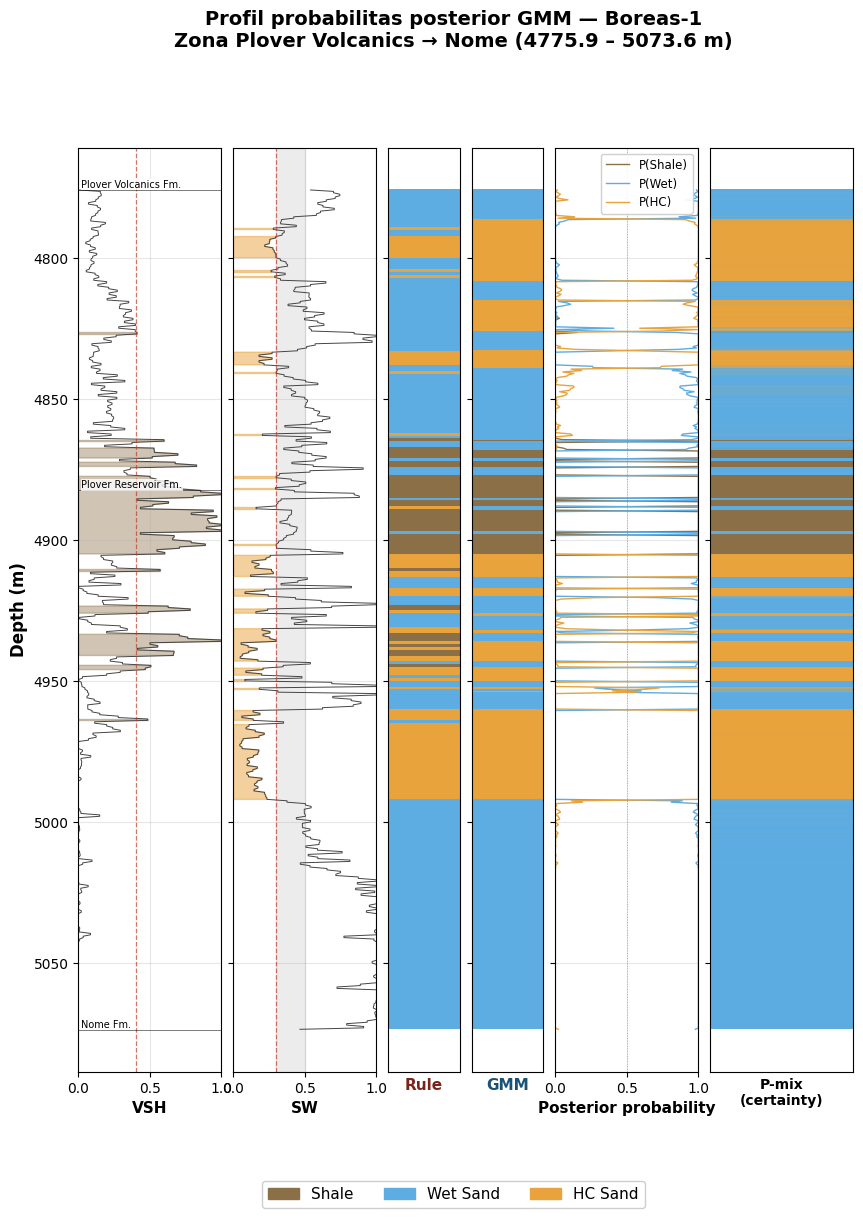

[Poseidon-1] n = 687 sampel valid
  Mean max-posterior probability : 0.988
  Fraksi sampel ambigu (P_max<0.65) : 1.0%
  Saved → pipeline_data\02_well_cond\figures\Poseidon-1_posterior_log_profile.png


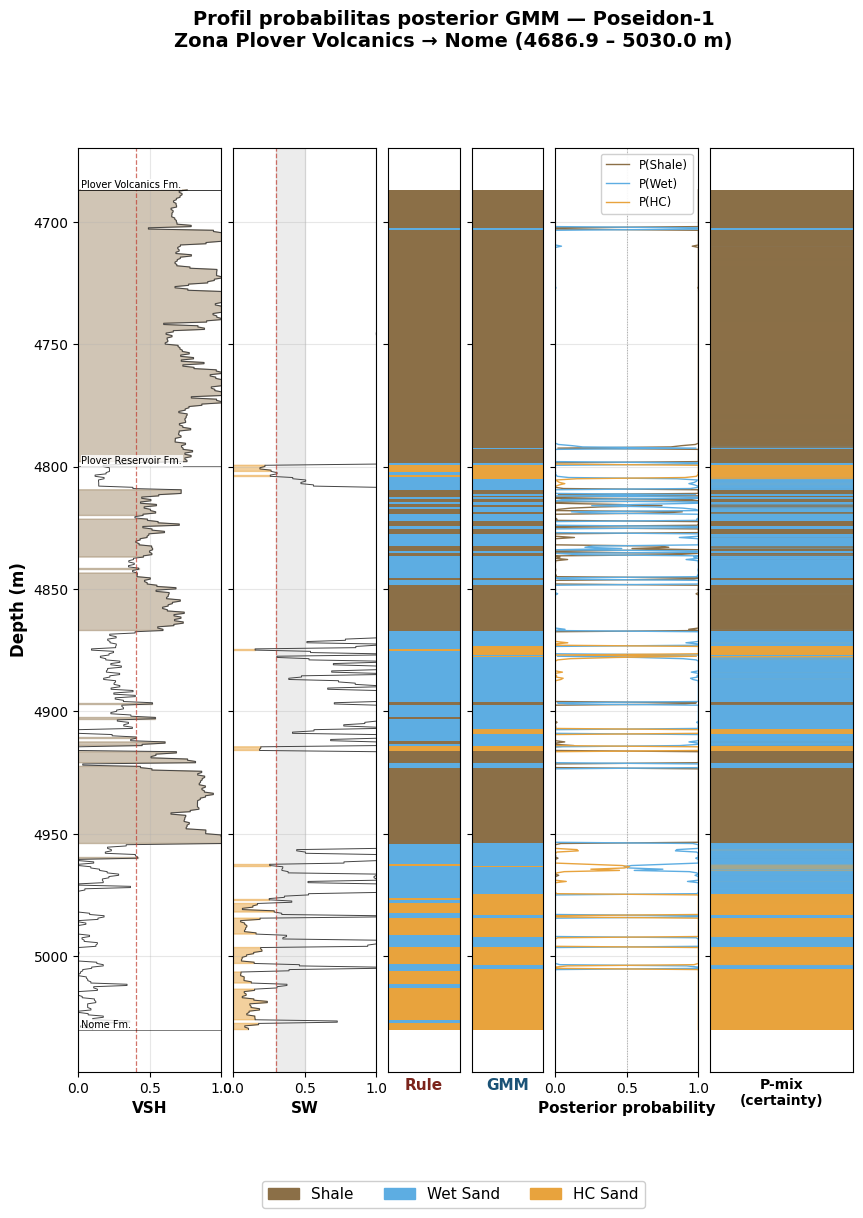


Komparasi ambiguitas:
  Boreas-1   : 1.0% sampel ambigu
  Poseidon-1 : 1.0% sampel ambigu


In [24]:
"""
Figure: Log profile probabilitas posterior GMM — versi tanpa PipelineIO.

Cukup beri root pipeline_data, sisanya dibaca langsung via
joblib / pickle / pandas. Tidak menyentuh PipelineIO sehingga
tahan terhadap perubahan API internalnya.

Struktur yang diharapkan (sudah sesuai pipeline NB1-NB2):
    pipeline_data/
    ├── 01_well_qc/
    │   ├── CFG.pkl
    │   └── WELL_TOPS.pkl
    └── 02_well_cond/
        ├── {well}.parquet            # log dgn kolom LITHO
        ├── SHARED_GMM.joblib
        └── SHARED_GMM_FEATS.pkl

Cara pakai:
    fig, stats = plot_posterior_log_profile('./pipeline_data', 'Boreas-1')
"""
import pickle
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
from pathlib import Path

# Palet warna (selaras dgn Figure 2 TA)
COLOR_SHALE = '#8B6F47'
COLOR_WET   = '#5DADE2'
COLOR_HC    = '#E8A33D'
LITHO_CMAP  = ListedColormap([COLOR_SHALE, COLOR_WET, COLOR_HC])
LITHO_NORM  = BoundaryNorm([0.5, 1.5, 2.5, 3.5], LITHO_CMAP.N)
RGB_SHALE   = np.array([139, 111,  71]) / 255
RGB_WET     = np.array([ 93, 173, 226]) / 255
RGB_HC      = np.array([232, 163,  61]) / 255


def _load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def plot_posterior_log_profile(pipeline_root='./pipeline_data',
                                well_name='Boreas-1',
                                depth_col='DEPT',
                                save=True,
                                ambig_threshold=0.65):
    """
    pipeline_root : str/Path — direktori root pipeline_data
    well_name     : 'Poseidon-1' atau 'Boreas-1'
    depth_col     : nama kolom kedalaman (auto-detect jika tidak ditemukan)
    """
    root = Path(pipeline_root)
    p_qc   = root / '01_well_qc'
    p_cond = root / '02_well_cond'

    # ---------- Load semua artefak ----------------------------------------
    well_tops = _load_pkl(p_qc   / 'WELL_TOPS.pkl')
    gmm       = joblib.load(p_cond / 'SHARED_GMM.joblib')
    feats     = _load_pkl(p_cond / 'SHARED_GMM_FEATS.pkl')
    df        = pd.read_parquet(p_cond / f'{well_name}.parquet')

    # Auto-detect kolom kedalaman jika 'DEPT' tidak ada
    if depth_col not in df.columns:
        for cand in ['DEPT', 'DEPTH', 'MD', 'TVD', 'Depth']:
            if cand in df.columns:
                depth_col = cand; break
        else:
            raise KeyError(f"Kolom kedalaman tidak ditemukan. "
                           f"Kolom tersedia: {list(df.columns)}")

    # ---------- Filter ke zona training -----------------------------------
    tops = well_tops[well_name]
    z_top = tops.get('Plover Volcanics Fm.')
    z_bot = tops.get('Nome Fm.')
    if z_top is None or z_bot is None:
        z_top, z_bot = df[depth_col].min(), df[depth_col].max()
        print(f'[WARN] Top/Bot formasi tidak ditemukan, pakai full range.')

    df = df[(df[depth_col] >= z_top) & (df[depth_col] <= z_bot)].copy()
    df = df.dropna(subset=feats).reset_index(drop=True)
    if len(df) == 0:
        raise ValueError(f'{well_name}: 0 sampel valid di zona target.')

    # ---------- Prediksi posterior ----------------------------------------
    X     = df[feats].values
    P     = gmm.predict_proba(X)            # (n, 3)
    P_max = P.max(axis=1)
    pred  = P.argmax(axis=1) + 1            # 1=Shale, 2=Wet, 3=HC

    depth = df[depth_col].values
    vsh   = df['VSH'].values
    sw    = df['SW'].values
    rule  = df['LITHO'].values.astype(int)
    gmm_l = pred

    # ---------- Plot ------------------------------------------------------
    fig = plt.figure(figsize=(10, 12))
    gs  = fig.add_gridspec(1, 6,
                           width_ratios=[0.8, 0.8, 0.4, 0.4, 0.8, 0.8],
                           wspace=0.10)

    # Track 1 — VSH
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(vsh, depth, color='#444', lw=0.7)
    ax1.fill_betweenx(depth, 0, vsh, where=(vsh > 0.40),
                      color=COLOR_SHALE, alpha=0.4)
    ax1.axvline(0.40, ls='--', color='#C0392B', lw=0.9, alpha=0.7)
    ax1.set_xlim(0, 1); ax1.set_xlabel('VSH', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Depth (m)', fontsize=12, fontweight='bold')
    ax1.invert_yaxis(); ax1.grid(alpha=0.3)

    # Track 2 — SW
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
    ax2.plot(sw, depth, color='#444', lw=0.7)
    ax2.fill_betweenx(depth, 0, sw, where=(sw < 0.30),
                      color=COLOR_HC, alpha=0.5)
    ax2.axvline(0.30, ls='--', color='#C0392B', lw=0.9, alpha=0.7)
    ax2.axvspan(0.30, 0.50, color='gray', alpha=0.15)
    ax2.set_xlim(0, 1); ax2.set_xlabel('SW', fontsize=11, fontweight='bold')
    ax2.tick_params(labelleft=False); ax2.grid(alpha=0.3)

    # Track 3 — Rule
    ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
    ax3.imshow(rule.reshape(-1, 1), aspect='auto',
               extent=[0, 1, depth[-1], depth[0]],
               cmap=LITHO_CMAP, norm=LITHO_NORM, interpolation='nearest')
    ax3.set_xticks([]); ax3.tick_params(labelleft=False)
    ax3.set_xlabel('Rule', fontsize=11, fontweight='bold', color='#7B241C')

    # Track 4 — GMM
    ax4 = fig.add_subplot(gs[0, 3], sharey=ax1)
    ax4.imshow(gmm_l.reshape(-1, 1), aspect='auto',
               extent=[0, 1, depth[-1], depth[0]],
               cmap=LITHO_CMAP, norm=LITHO_NORM, interpolation='nearest')
    ax4.set_xticks([]); ax4.tick_params(labelleft=False)
    ax4.set_xlabel('GMM', fontsize=11, fontweight='bold', color='#1A5276')

    # Track 5 — Posterior curves
    ax5 = fig.add_subplot(gs[0, 4], sharey=ax1)
    ax5.plot(P[:, 0], depth, color=COLOR_SHALE, lw=1.0, label='P(Shale)')
    ax5.plot(P[:, 1], depth, color=COLOR_WET,   lw=1.0, label='P(Wet)')
    ax5.plot(P[:, 2], depth, color=COLOR_HC,    lw=1.0, label='P(HC)')
    ax5.axvline(0.5, ls=':', color='gray', lw=0.7, alpha=0.6)
    ax5.set_xlim(0, 1)
    ax5.set_xlabel('Posterior probability', fontsize=11, fontweight='bold')
    ax5.tick_params(labelleft=False); ax5.grid(alpha=0.3)
    ax5.legend(loc='upper right', fontsize=8.5, framealpha=0.92)

    # Track 6 — Stacked P (RGB mixing → visualisasi certainty)
    ax6 = fig.add_subplot(gs[0, 5], sharey=ax1)
    rgb = (P[:, [0]] * RGB_SHALE +
           P[:, [1]] * RGB_WET   +
           P[:, [2]] * RGB_HC).reshape(-1, 1, 3)
    ax6.imshow(rgb, aspect='auto',
               extent=[0, 1, depth[-1], depth[0]], interpolation='nearest')
    ax6.set_xticks([]); ax6.tick_params(labelleft=False)
    ax6.set_xlabel('P-mix\n(certainty)', fontsize=10, fontweight='bold')

    # Anotasi formasi tops
    for fm_name, fm_depth in tops.items():
        if z_top <= fm_depth <= z_bot:
            ax1.axhline(fm_depth, color='k', lw=0.6, alpha=0.6)
            ax1.text(0.02, fm_depth, fm_name, fontsize=7,
                     va='bottom', ha='left',
                     bbox=dict(facecolor='white', edgecolor='none',
                               alpha=0.8, pad=0.5))

    # Legend
    handles = [Rectangle((0, 0), 1, 1, color=c, label=l)
               for c, l in zip([COLOR_SHALE, COLOR_WET, COLOR_HC],
                               ['Shale', 'Wet Sand', 'HC Sand'])]
    fig.legend(handles=handles, loc='lower center', ncol=3,
               fontsize=11, framealpha=0.95, bbox_to_anchor=(0.5, -0.01))

    fig.suptitle(f'Profil probabilitas posterior GMM — {well_name}\n'
                 f'Zona Plover Volcanics → Nome ({z_top:.1f} – {z_bot:.1f} m)',
                 fontsize=14, fontweight='bold', y=0.995)

    # Statistik
    frac_ambig = (P_max < ambig_threshold).mean() * 100
    p_max_mean = P_max.mean()
    print(f'[{well_name}] n = {len(df)} sampel valid')
    print(f'  Mean max-posterior probability : {p_max_mean:.3f}')
    print(f'  Fraksi sampel ambigu (P_max<{ambig_threshold}) : {frac_ambig:.1f}%')

    if save:
        outdir = p_cond / 'figures'
        outdir.mkdir(exist_ok=True, parents=True)
        outpath = outdir / f'{well_name}_posterior_log_profile.png'
        plt.savefig(outpath, dpi=200, bbox_inches='tight', facecolor='white')
        print(f'  Saved → {outpath}')
    plt.show()
    return fig, {'P': P, 'pred': gmm_l, 'depth': depth,
                 'frac_ambig': frac_ambig, 'p_max_mean': p_max_mean}


# ============================================================================
# CARA PAKAI — paste sebagai cell baru di NB2 (setelah GMM training):
# ============================================================================
#
fig_b, stats_b = plot_posterior_log_profile('./pipeline_data', 'Boreas-1')
fig_p, stats_p = plot_posterior_log_profile('./pipeline_data', 'Poseidon-1')
#
print(f"\nKomparasi ambiguitas:")
print(f"  Boreas-1   : {stats_b['frac_ambig']:.1f}% sampel ambigu")
print(f"  Poseidon-1 : {stats_p['frac_ambig']:.1f}% sampel ambigu")